# TechLive coordination – cost-benefit model

**Module:** Data Informed Solutions (DT504) – Part A, Appendix C
**Author:** Muna Lemeh

This notebook reproduces every figure in the investment proposal:

1. The baseline cost of coordinating TechLive manually (Section 4.2)
2. The cost-benefit comparison of four options (Section 4.3)
3. The cumulative net saving chart (Section 4.3)
4. The weighted scoring matrix (Section 4.4)
5. The best, base and worst case scenarios and sensitivity checks (Section 5.2)

All inputs are organiser estimates based on three TechLive events, not recorded data. They sit in one place (the next cell) so they can be replaced with real figures later.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Assumptions

Global settings apply to every option. Each option then has its own estimates for organiser hours, host hours, catering and costs (Appendix B of the proposal).

In [2]:
# Global assumptions
HOURLY_RATE = 40        # £ per hour, blended staff cost (assumption)
EVENTS_PER_YEAR = 3
ROOMS_PER_EVENT = 40
ACTUAL_ATTENDANCE = 9   # people who actually turn up per room
COST_PER_HEAD = 8 + 5   # £8 food + £5 goodie bag

# Organiser hours per event, by task
tasks = pd.DataFrame({
    "Task": ["Timezone matching", "Finding hosts", "Room bookings",
             "Forms and chasing", "Catering orders", "Invites"],
    "A": [1, 12, 8, 6, 5, 6],
    "B": [0.5, 8, 6, 1.5, 2, 2],
    "C": [0.5, 3, 3, 1, 1.5, 1],
    "D": [1, 5, 6, 0.5, 1.5, 0],
}).set_index("Task")

# Other inputs per option
options = pd.DataFrame({
    "Option": ["A. Do nothing", "B. Planner + Power Automate",
               "C. Power Apps hub", "D. Events platform"],
    "host_hours_per_room": [1.5, 1.5, 1.0, 1.0],
    "heads_ordered_per_room": [15, 12, 11, 11],
    "build_hours": [0, 80, 240, 120],
    "implementation_fee": [0, 0, 0, 8000],
    "maintenance_hours_per_year": [0, 24, 60, 40],
    "licence_per_year": [0, 0, 300, 14000],
}, index=["A", "B", "C", "D"])
options["organiser_hours"] = tasks.sum()

tasks.loc["Total"] = tasks.sum()
tasks

,A,B,C,D
Task,,,,
Timezone matching,1.0,0.5,0.5,1.0
Finding hosts,12.0,8.0,3.0,5.0
Room bookings,8.0,6.0,3.0,6.0
Forms and chasing,6.0,1.5,1.0,0.5
Catering orders,5.0,2.0,1.5,1.5
Invites,6.0,2.0,1.0,0.0
Total,38.0,20.0,10.0,14.0


## 2. The cost model

For each option:

- **Staff cost per event** = (organiser hours + host hours × rooms) × hourly rate
- **Catering per event** = heads ordered × rooms × cost per head
- **Annual running cost** = events × (staff + catering) + maintenance hours × rate + licence
- **One-off cost** = build hours × rate + implementation fee
- **Payback (months)** = one-off cost ÷ annual saving × 12
- **3-year net saving** = 3 × annual saving − one-off cost

In [3]:
def cost_model(opts, rate=HOURLY_RATE, events=EVENTS_PER_YEAR,
               rooms=ROOMS_PER_EVENT, build_multiplier=1.0):
    df = pd.DataFrame(index=opts.index)
    df["Option"] = opts["Option"]
    staff_hours = opts["organiser_hours"] + opts["host_hours_per_room"] * rooms
    df["Staff cost per event"] = staff_hours * rate
    df["Catering per event"] = opts["heads_ordered_per_room"] * rooms * COST_PER_HEAD
    df["Catering wasted per event"] = (
        (opts["heads_ordered_per_room"] - ACTUAL_ATTENDANCE) * rooms * COST_PER_HEAD)
    df["Annual running cost"] = (
        events * (df["Staff cost per event"] + df["Catering per event"])
        + opts["maintenance_hours_per_year"] * rate + opts["licence_per_year"])
    df["One-off cost"] = (opts["build_hours"] * build_multiplier * rate
                          + opts["implementation_fee"])
    df["Annual saving vs A"] = df.loc["A", "Annual running cost"] - df["Annual running cost"]
    df["Payback (months)"] = [
        round(one / save * 12, 1) if save > 0 else None
        for one, save in zip(df["One-off cost"], df["Annual saving vs A"])]
    df["3-year net saving"] = 3 * df["Annual saving vs A"] - df["One-off cost"]
    return df

results = cost_model(options)

## 3. Baseline cost (Option A)

In [4]:
a = results.loc["A"]
print(f"Staff cost per event:      £{a['Staff cost per event']:,.0f}")
print(f"Catering per event:        £{a['Catering per event']:,.0f}")
print(f"  of which wasted:         £{a['Catering wasted per event']:,.0f}")
print(f"Annual running cost:       £{a['Annual running cost']:,.0f}")
print(f"Annual catering waste:     £{a['Catering wasted per event'] * EVENTS_PER_YEAR:,.0f}")

Staff cost per event:      £3,920
Catering per event:        £7,800
  of which wasted:         £3,120
Annual running cost:       £35,160
Annual catering waste:     £9,360


## 4. Cost-benefit comparison

In [5]:
summary = results[["Option", "One-off cost", "Annual running cost",
                   "Annual saving vs A", "Payback (months)", "3-year net saving"]]
summary

,Option,One-off cost,Annual running cost,Annual saving vs A,Payback (months),3-year net saving
A,A. Do nothing,0.0,35160.0,0.0,NaN,0.0
B,B. Planner + Power Automate,3200.0,29280.0,5880.0,6.5,14440.0
C,C. Power Apps hub,9600.0,25860.0,9300.0,12.4,18300.0
D,D. Events platform,12800.0,39240.0,-4080.0,NaN,-25040.0


## 5. Cumulative net saving chart

Each line starts at minus the one-off cost and rises (or falls) by the annual saving each year. Option A, doing nothing, is the £0 line.

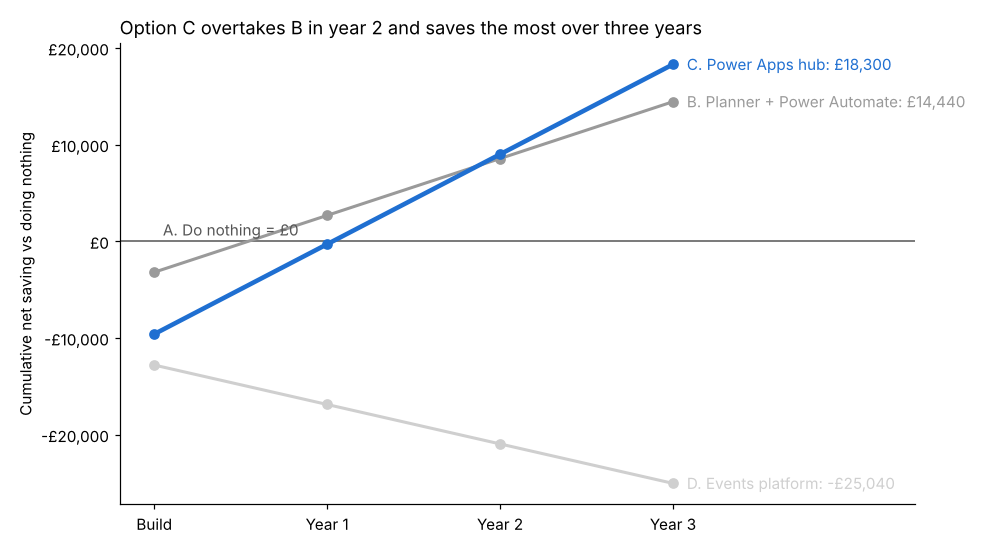

In [6]:
def pounds(v):
    return f"-£{abs(v):,.0f}" if v < 0 else f"£{v:,.0f}"

years = [0, 1, 2, 3]
labels = ["Build", "Year 1", "Year 2", "Year 3"]
styles = {"B": ("#9a9a9a", 2), "C": ("#1f6fd1", 3), "D": ("#cfcfcf", 2)}

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color="#555555", linewidth=1)
ax.text(0.05, 600, "A. Do nothing = £0", color="#555555")
for key, (colour, width) in styles.items():
    row = results.loc[key]
    values = [-row["One-off cost"] + y * row["Annual saving vs A"] for y in years]
    ax.plot(years, values, marker="o", color=colour, linewidth=width)
    ax.text(3.08, values[-1], f"{row['Option']}: {pounds(values[-1])}",
            va="center", color=colour)

ax.set_xticks(years, labels)
ax.yaxis.set_major_formatter(lambda v, _: pounds(v))
ax.set_title("Option C overtakes B in year 2 and saves the most over three years",
             loc="left")
ax.set_ylabel("Cumulative net saving vs doing nothing")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(-0.2, 4.4)
plt.tight_layout()
plt.show()

## 6. Weighted scoring

Each option is scored 1 (poor) to 5 (strong) on each criterion, then multiplied by the criterion's weight.

In [7]:
weights = pd.Series({
    "3-year financial benefit": 0.30,
    "Delivery risk": 0.20,
    "Fit with Microsoft stack and governance": 0.20,
    "Time to value": 0.15,
    "Scalability and user experience": 0.15,
})
scores = pd.DataFrame({
    "A": [1, 3, 5, 1, 1],
    "B": [4, 5, 5, 5, 3],
    "C": [5, 3, 5, 3, 5],
    "D": [1, 2, 2, 2, 5],
}, index=weights.index)

assert abs(weights.sum() - 1) < 1e-9, "weights must add up to 100%"
weighted = scores.mul(weights, axis=0).sum().round(2)
scores.loc["Weighted score"] = weighted
scores

,A,B,C,D
3-year financial benefit,1.0,4.0,5.0,1.00
Delivery risk,3.0,5.0,3.0,2.00
Fit with Microsoft stack and governance,5.0,5.0,5.0,2.00
Time to value,1.0,5.0,3.0,2.00
Scalability and user experience,1.0,3.0,5.0,5.00
Weighted score,2.2,4.4,4.3,2.15


## 7. Scenario planning for Option C

- **Best:** build 15% faster, full savings, 4 events a year
- **Base:** as modelled
- **Worst:** build 50% over, half the savings realised, 2 events a year

In [8]:
def scenario(key, build_multiplier, realised, events, rate=HOURLY_RATE):
    r = cost_model(options, rate=rate, events=events, build_multiplier=build_multiplier)
    saving = r.loc[key, "Annual saving vs A"] * realised
    one_off = r.loc[key, "One-off cost"]
    return {"One-off cost": one_off, "Annual saving": saving,
            "3-year net": 3 * saving - one_off}

scenarios = pd.DataFrame({
    "Best": scenario("C", 0.85, 1.0, 4),
    "Base": scenario("C", 1.0, 1.0, 3),
    "Worst": scenario("C", 1.5, 0.5, 2),
}).T.round(0)
scenarios

,One-off cost,Annual saving,3-year net
Best,8160.0,13300.0,31740.0
Base,9600.0,9300.0,18300.0
Worst,14400.0,2650.0,-6450.0


### Why phasing helps, and sensitivity to the hourly rate

The worst case loses money if Option C is approved in full. If only Phase 1 (Option B) is committed first, the same worst case roughly breaks even. Because most savings come from catering, the result barely changes if the hourly rate is £30 instead of £40.

In [9]:
phase1_worst = scenario("B", 1.5, 0.5, 2)
print(f"Phase 1 only, worst case, 3-year net: £{phase1_worst['3-year net']:,.0f}")

at_30 = cost_model(options, rate=30).loc["C", "3-year net saving"]
print(f"Option C 3-year net saving at £30/hour: £{at_30:,.0f}")

Phase 1 only, worst case, 3-year net: £600
Option C 3-year net saving at £30/hour: £18,180


## 8. Conclusion

Option C gives the largest three-year saving and Option B the fastest payback, while Option D costs more than doing nothing at TechLive's current scale. Delivering B first, with a review gate before C, keeps the worst case close to break-even.

**Next step:** replace the estimates in Section 1 with recorded attendance, hours and catering data from the next event, then re-run the notebook.